# TOPICS COVERED
    - SPARK BASIC ARCHITECTURE
    
    - SPARK APPLICATIONS
    
    - DATAFRAME
    
    - PARTITIONS
    
    - TRANSFORMATIONS
    
    - ACTIONS
    
    - HOW TO USE SQL IN SPARK

# SPARK BASIC ARCHITRCTURE
    -A cluster, or group, of computers, pools the resources of many machines together, giving us the ability to use all the cumulative resources as if they were a single computer. Now, a group of machines alone is not powerful, you need a framework to coordinate work across them. Spark does just that, managing and coordinating the execution of tasks on data across a cluster of computers.

    -The cluster of machines that Spark will use to execute tasks is managed by a cluster manager like Spark’s standalone cluster manager, YARN, or Mesos. We then submit Spark Applications to these cluster managers, which will grant resources to our application so that we can complete our work.



# SPARK APPLICATIONS
    -Spark Applications consist of a driver process and a set of executor processes
  
    -The driver process runs your main() function, sits on a node in the cluster, and is responsible for three things: maintaining information about the Spark Application; responding to a user’s program or input; and analyzing, distributing, and scheduling work across the executors

    -The executors are responsible for actually carrying out the work that the driver assigns them.

    -Figure demonstrates how the cluster manager controls physical machines and allocates resources to Spark Applications

    -This can be one of three core cluster managers: Spark’s standalone cluster manager, YARN, or Mesos.

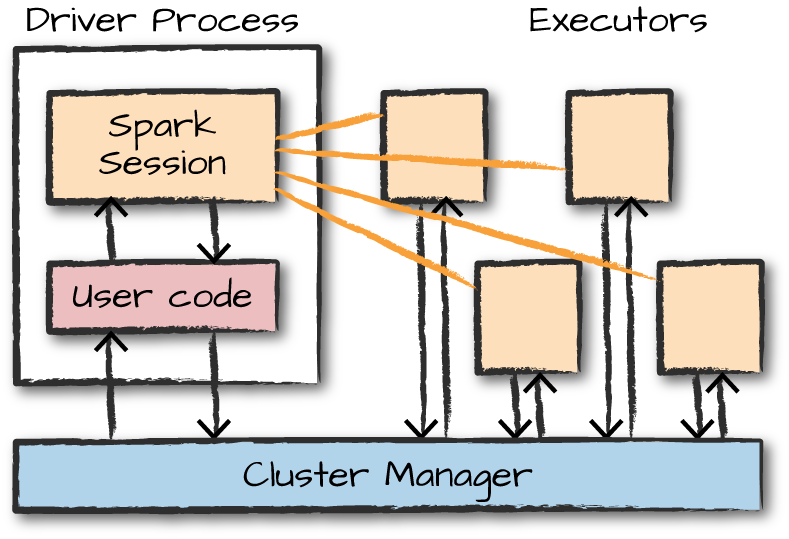
  

# DATAFRAMES
    -A DataFrame is the most common Structured API and simply represents a table of data with rows and columns.

    -The list that defines the columns and the types within those columns is called the schema.


# PARTITIONS
    -To allow every executor to perform work in parallel, Spark breaks up the data into chunks called partitions.

    -A partition is a collection of rows that sit on one physical machine in your cluster

# TRANSFORMATIONS
    -The core data structures are immutable, meaning they cannot be changed after they’re created.

    -To “change” a DataFrame, you need to instruct Spark how you would like to modify it to do what you want. These instructions are called transformations.

    -There are two types of transformations: those that specify narrow dependencies, and those that specify wide dependencies.

## NARROW TRANSFORMATION
    -Those for which each input partition will contribute to only one output partition.

    -Only one partition contributes to at most one output partition

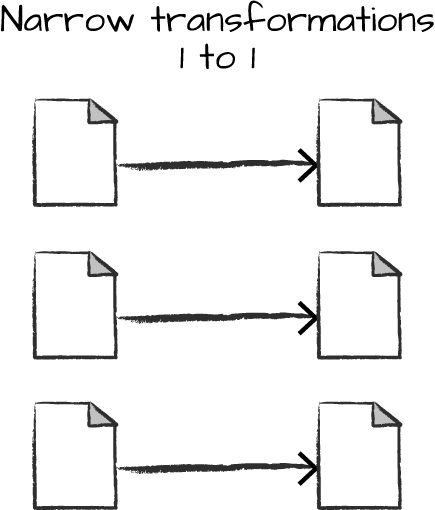

## WIDE TRANSFORMATION
    -Input partitions contributing to many output partitions.
    
    -You will often hear this referred to as a shuffle whereby Spark will exchange partitions across the cluster.

<img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781491912201/files/assets/spdg_0205.png" width="300">

## LAZY EVALUATION
    -Lazy evaulation means that Spark will wait until the very last moment to execute the graph of computation instructions

# ACTIONS
    -Transformations allow us to build up our logical transformation plan. To trigger the computation, we run an action. An action instructs Spark to compute a result from a series of transformations. The simplest action is count, which gives us the total number of records in the DataFrame

# An End-to-End Example

In [58]:
from pyspark.sql import SparkSession
spark=SparkSession.builder.appName('Practice').getOrCreate();
flightData2015=spark.read.csv('file:///home/unik/Pyspark_Practice/2015-summary.csv',header=True,inferSchema=True)

<img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781491912201/files/assets/spdg_0207.png" width="700">

In [47]:
flightData2015.show()

+--------------------+-------------------+-----+
|   DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|
+--------------------+-------------------+-----+
|       United States|            Romania|   15|
|       United States|            Croatia|    1|
|       United States|            Ireland|  344|
|               Egypt|      United States|   15|
|       United States|              India|   62|
|       United States|          Singapore|    1|
|       United States|            Grenada|   62|
|          Costa Rica|      United States|  588|
|             Senegal|      United States|   40|
|             Moldova|      United States|    1|
|       United States|       Sint Maarten|  325|
|       United States|   Marshall Islands|   39|
|              Guyana|      United States|   64|
|               Malta|      United States|    1|
|            Anguilla|      United States|   41|
|             Bolivia|      United States|   30|
|       United States|           Paraguay|    6|
|             Algeri

In [48]:
flightData2015.take(3)

[Row(DEST_COUNTRY_NAME='United States', ORIGIN_COUNTRY_NAME='Romania', count=15),
 Row(DEST_COUNTRY_NAME='United States', ORIGIN_COUNTRY_NAME='Croatia', count=1),
 Row(DEST_COUNTRY_NAME='United States', ORIGIN_COUNTRY_NAME='Ireland', count=344)]

    -Remember, sort does not modify the DataFrame. We use sort as a transformation that returns a new DataFrame by transforming the previous DataFrame.
    -We can call explain on any DataFrame object to see the DataFrame’s lineage (or how Spark will execute this query)
<img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781491912201/files/assets/spdg_0208.png" width="700">

In [49]:
flightData2015.sort('count').explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [count#368 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(count#368 ASC NULLS FIRST, 200), ENSURE_REQUIREMENTS, [plan_id=722]
      +- FileScan csv [DEST_COUNTRY_NAME#366,ORIGIN_COUNTRY_NAME#367,count#368] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/home/unik/Pyspark_Practice/2015-summary.csv], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<DEST_COUNTRY_NAME:string,ORIGIN_COUNTRY_NAME:string,count:int>




# DATAFRAMES AND SQL
    -We can express our business logic in SQL or DataFrames (either in R, Python, Scala, or Java) and Spark will compile that logic down to an underlying plan (that you can see in the explain plan) before actually executing your code.
    
    -With Spark SQL, you can register any DataFrame as a table or view (a temporary table) and query it using pure SQL

In [61]:
#Dataframe to table or view
flightData2015.createOrReplaceTempView('flight_data_2015')
sqlway=spark.sql("""
SELECT DEST_COUNTRY_NAME,count(1)
FROM flight_data_2015
GROUP BY DEST_COUNTRY_NAME 
""")
dataFrameWay=flightData2015.groupBy('DEST_COUNTRY_NAME').count()

In [53]:
sqlway.explain()
dataFrameWay.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[DEST_COUNTRY_NAME#366], functions=[count(1)])
   +- Exchange hashpartitioning(DEST_COUNTRY_NAME#366, 200), ENSURE_REQUIREMENTS, [plan_id=738]
      +- HashAggregate(keys=[DEST_COUNTRY_NAME#366], functions=[partial_count(1)])
         +- FileScan csv [DEST_COUNTRY_NAME#366] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/home/unik/Pyspark_Practice/2015-summary.csv], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<DEST_COUNTRY_NAME:string>


== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[DEST_COUNTRY_NAME#366], functions=[count(1)])
   +- Exchange hashpartitioning(DEST_COUNTRY_NAME#366, 200), ENSURE_REQUIREMENTS, [plan_id=751]
      +- HashAggregate(keys=[DEST_COUNTRY_NAME#366], functions=[partial_count(1)])
         +- FileScan csv [DEST_COUNTRY_NAME#366] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileInd

# TOP 5 DESTINATION COUNTRIES IN THE DATA

In [54]:
spark.sql('SELECT max(count) FROM flight_data_2015').take(1)
from pyspark.sql.functions import *
flightData2015.select(max('count')).take(1)

[Row(max(count)=370002)]

In [62]:
#USING SQL QUERY
maxSql = spark.sql("""
SELECT DEST_COUNTRY_NAME, sum(count) as destination_total
FROM flight_data_2015
GROUP BY DEST_COUNTRY_NAME
ORDER BY sum(count) DESC
LIMIT 5
""")
maxSql.show()

+-----------------+-----------------+
|DEST_COUNTRY_NAME|destination_total|
+-----------------+-----------------+
|    United States|           411352|
|           Canada|             8399|
|           Mexico|             7140|
|   United Kingdom|             2025|
|            Japan|             1548|
+-----------------+-----------------+



In [59]:
from pyspark.sql.functions import desc
# flightData2015.groupBy('DEST_COUNTRY_NAME').sum('count').sort(desc(sum('count'))).show()
flightData2015\
  .groupBy("DEST_COUNTRY_NAME")\
  .sum("count")\
  .withColumnRenamed("sum(count)", "destination_total")\
  .sort(desc("destination_total"))\
  .limit(5)\
  .show()

+-----------------+-----------------+
|DEST_COUNTRY_NAME|destination_total|
+-----------------+-----------------+
|    United States|           411352|
|           Canada|             8399|
|           Mexico|             7140|
|   United Kingdom|             2025|
|            Japan|             1548|
+-----------------+-----------------+



In [57]:
# flightData2015.groupBy('DEST_COUNTRY_NAME').sum('count').sort(desc(sum('count'))).show()
flightData2015\
  .groupBy("DEST_COUNTRY_NAME")\
  .sum("count")\
  .withColumnRenamed("sum(count)", "destination_total")\
  .sort(desc("destination_total"))\
  .limit(5)\
  .explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- TakeOrderedAndProject(limit=5, orderBy=[destination_total#475L DESC NULLS LAST], output=[DEST_COUNTRY_NAME#366,destination_total#475L])
   +- HashAggregate(keys=[DEST_COUNTRY_NAME#366], functions=[sum(count#368)])
      +- Exchange hashpartitioning(DEST_COUNTRY_NAME#366, 200), ENSURE_REQUIREMENTS, [plan_id=921]
         +- HashAggregate(keys=[DEST_COUNTRY_NAME#366], functions=[partial_sum(count#368)])
            +- FileScan csv [DEST_COUNTRY_NAME#366,count#368] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/home/unik/Pyspark_Practice/2015-summary.csv], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<DEST_COUNTRY_NAME:string,count:int>




## The Entire Dataframe Transformation Flow
<img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781491912201/files/assets/spdg_0210.png" width="700">